# League of Legends player mobility network, 2015–2019

**Research question:** Is a team's position in the 2015–2019 professional League of Legends player-mobility network associated with domestic performance and recorded international participation?

The data were derived from the Leaguepedia MediaWiki Cargo API and processed afterward. The raw API responses and original collection script are unavailable. The processed lineage identifiers in `player_node` and `team_node` are used as provided. International matches are not separated into MSI and Worlds, so this notebook uses the term **recorded international participation**. Shared players show association, not transfer direction or reasons for movement.

## 1. Setup and data validation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
from networkx.algorithms import bipartite
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, spearmanr

SEED = 403
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

ROOT = Path.cwd()
if not (ROOT / "data" / "processed" / "affiliations.csv").exists():
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data" / "processed" / "affiliations.csv"

raw = pd.read_csv(DATA_PATH)
required_columns = {
    "player_node", "team_node", "player_name", "team_name",
    "team_name_at_time", "team_name_history", "group", "leagues",
    "minutes_domestic", "games_domestic", "wins_domestic",
    "first_date", "last_date", "active_years",
    "minutes_international", "games_international", "wins_international",
    "minutes_total", "games_total", "wins_total", "domestic_win_rate",
}
missing_columns = required_columns.difference(raw.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")
if raw[["player_node", "team_node"]].isna().any().any():
    raise ValueError("player_node and team_node must not be missing")

raw["first_date"] = pd.to_datetime(raw["first_date"], utc=True)
raw["last_date"] = pd.to_datetime(raw["last_date"], utc=True)

def split_values(values):
    result = set()
    for value in values:
        result.update(
            part.strip() for part in str(value).split("|")
            if part.strip() and part.strip().lower() != "nan"
        )
    return sorted(result)

def split_years(values):
    return sorted({int(part) for part in split_values(values)})

covered_years = split_years(raw["active_years"])
validation_summary = pd.DataFrame(
    {
        "item": [
            "Rows", "Columns", "Exact duplicate rows",
            "Duplicate player-team rows beyond first", "Unique players",
            "Unique team lineages", "Leagues", "Groups", "Covered years",
        ],
        "value": [
            len(raw), len(raw.columns), raw.duplicated().sum(),
            raw.duplicated(["player_node", "team_node"]).sum(),
            raw["player_node"].nunique(), raw["team_node"].nunique(),
            ", ".join(sorted(raw["leagues"].unique())),
            ", ".join(sorted(raw["group"].unique())),
            ", ".join(map(str, covered_years)),
        ],
    }
)
missing_value_summary = (
    raw.isna().sum().rename("missing_values").to_frame()
       .assign(missing_share=lambda x: x["missing_values"] / len(raw))
)
column_summary = pd.DataFrame({"column": raw.columns, "dtype": raw.dtypes.astype(str).values})

display(validation_summary)
display(column_summary)
display(missing_value_summary)

,item,value
0,Rows,3561
1,Columns,21
2,Exact duplicate rows,0
3,Duplicate player-team rows beyond first,134
4,Unique players,2029
5,Unique team lineages,244
6,Leagues,"CBLOL, LCK, LCL, LCS, LEC, LJL, LMS, LPL, OPL,..."
7,Groups,"major, wildcard"
8,Covered years,"2015, 2016, 2017, 2018, 2019"


,column,dtype
0,player_node,object
1,team_node,object
2,player_name,object
3,team_name,object
4,team_name_at_time,object
5,team_name_history,object
6,group,object
7,leagues,object
8,minutes_domestic,float64
9,games_domestic,int64


,missing_values,missing_share
player_node,0,0.0
team_node,0,0.0
player_name,0,0.0
team_name,0,0.0
team_name_at_time,0,0.0
team_name_history,0,0.0
group,0,0.0
leagues,0,0.0
minutes_domestic,0,0.0
games_domestic,0,0.0


### Aggregate player–team pairs

In [2]:
numeric_edge_columns = [
    "minutes_domestic", "games_domestic", "wins_domestic",
    "minutes_international", "games_international", "wins_international",
    "minutes_total", "games_total", "wins_total",
]

def join_values(values):
    return " | ".join(split_values(values))

aggregation = {
    "player_name": "last",
    "team_name": "last",
    "team_name_at_time": join_values,
    "team_name_history": join_values,
    "group": join_values,
    "leagues": join_values,
    "first_date": "min",
    "last_date": "max",
    "active_years": lambda x: "|".join(map(str, split_years(x))),
}
aggregation.update({column: "sum" for column in numeric_edge_columns})

edge_table = (
    raw.groupby(["player_node", "team_node"], as_index=False, sort=True)
       .agg(aggregation)
)
edge_table["domestic_win_rate"] = edge_table["wins_domestic"].div(
    edge_table["games_domestic"].replace(0, np.nan)
)

assert not edge_table.duplicated(["player_node", "team_node"]).any()
assert np.allclose(
    raw[numeric_edge_columns].sum().to_numpy(dtype=float),
    edge_table[numeric_edge_columns].sum().to_numpy(dtype=float),
)
print(f"Aggregated to {len(edge_table):,} unique player-team edges; numeric totals are preserved.")

Aggregated to 3,427 unique player-team edges; numeric totals are preserved.


## 2. Player–team bipartite graph

This is an undirected weighted bipartite graph. Edge weight is `games_total`. Degree counts affiliations; strength sums recorded games.

In [3]:
B = nx.Graph(name="Player-team lineage bipartite graph")

for row in edge_table.itertuples(index=False):
    display_group = "minor" if row.group == "wildcard" else row.group
    B.add_node(row.player_node, node_type="player", bipartite=0, label=row.player_name)
    B.add_node(
        row.team_node, node_type="team", bipartite=1, label=row.team_name,
        league=row.leagues, group=row.group, display_group=display_group,
        team_name_at_time=row.team_name_at_time,
        team_name_history=row.team_name_history,
    )
    B.add_edge(
        row.player_node, row.team_node,
        weight=float(row.games_total), games_total=float(row.games_total),
        games_domestic=float(row.games_domestic),
        wins_domestic=float(row.wins_domestic),
        minutes_domestic=float(row.minutes_domestic),
        games_international=float(row.games_international),
        wins_international=float(row.wins_international),
        minutes_international=float(row.minutes_international),
        minutes_total=float(row.minutes_total), wins_total=float(row.wins_total),
        first_date=row.first_date.isoformat(), last_date=row.last_date.isoformat(),
        active_years=row.active_years,
        team_name_at_time=row.team_name_at_time,
        team_name_history=row.team_name_history,
    )

assert not B.is_directed() and bipartite.is_bipartite(B)
player_nodes = {n for n, a in B.nodes(data=True) if a["node_type"] == "player"}
team_nodes = set(B) - player_nodes
components = sorted((len(c) for c in nx.connected_components(B)), reverse=True)

bipartite_summary = pd.DataFrame(
    {
        "metric": [
            "Graph type", "Nodes", "Edges", "Players", "Teams",
            "Bipartite density", "Connected components", "Giant component size",
            "Giant component share", "Average player bipartite clustering",
            "Average team bipartite clustering",
        ],
        "value": [
            "Undirected weighted bipartite", B.number_of_nodes(), B.number_of_edges(),
            len(player_nodes), len(team_nodes), bipartite.density(B, player_nodes),
            len(components), components[0], components[0] / B.number_of_nodes(),
            bipartite.average_clustering(B, nodes=player_nodes),
            bipartite.average_clustering(B, nodes=team_nodes),
        ],
    }
)

def distribution_summary(values, node_type, measure):
    series = pd.Series(values, dtype=float)
    return {
        "node_type": node_type, "measure": measure, "count": len(series),
        "min": series.min(), "q25": series.quantile(0.25),
        "median": series.median(), "mean": series.mean(),
        "q75": series.quantile(0.75), "max": series.max(),
    }

bipartite_distributions = pd.DataFrame([
    distribution_summary([B.degree(n) for n in player_nodes], "player", "degree"),
    distribution_summary([B.degree(n) for n in team_nodes], "team", "degree"),
    distribution_summary([B.degree(n, weight="weight") for n in player_nodes], "player", "strength"),
    distribution_summary([B.degree(n, weight="weight") for n in team_nodes], "team", "strength"),
])
component_size_distribution = pd.DataFrame(
    {"component_rank": range(1, len(components) + 1), "nodes": components}
).assign(share=lambda x: x["nodes"] / B.number_of_nodes())

display(bipartite_summary.round(4))
display(bipartite_distributions.round(2))
display(component_size_distribution.head(15).round(4))

,metric,value
0,Graph type,Undirected weighted bipartite
1,Nodes,2273
2,Edges,3427
3,Players,2029
4,Teams,244
5,Bipartite density,0.006922
6,Connected components,17
7,Giant component size,2157
8,Giant component share,0.948966
9,Average player bipartite clustering,0.519932


,node_type,measure,count,min,q25,median,mean,q75,max
0,player,degree,2029,1.0,1.00,1.0,1.69,2.00,7.0
1,team,degree,244,5.0,7.00,11.0,14.05,19.25,57.0
2,player,strength,2029,1.0,9.00,32.0,73.90,101.00,565.0
3,team,strength,244,10.0,108.75,360.0,614.50,921.25,3115.0


,component_rank,nodes,share
0,1,2157,0.9490
1,2,9,0.0040
2,3,9,0.0040
3,4,9,0.0040
4,5,8,0.0035
5,6,8,0.0035
6,7,8,0.0035
7,8,8,0.0035
8,9,7,0.0031
9,10,7,0.0031


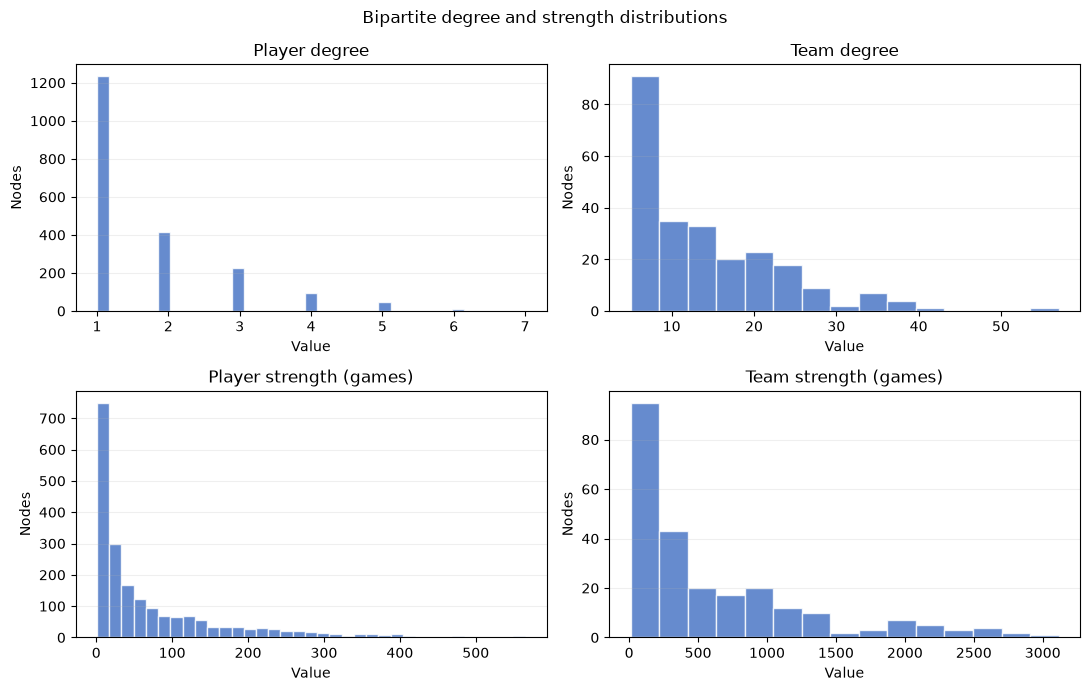

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
distribution_plots = [
    (player_nodes, "degree", "Player degree"),
    (team_nodes, "degree", "Team degree"),
    (player_nodes, "strength", "Player strength (games)"),
    (team_nodes, "strength", "Team strength (games)"),
]
for ax, (nodes, measure, title) in zip(axes.flat, distribution_plots):
    values = [B.degree(n, weight="weight" if measure == "strength" else None) for n in nodes]
    bins = min(35, max(10, int(np.sqrt(len(values)))))
    ax.hist(values, bins=bins, color="#4472C4", alpha=0.82, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Nodes")
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Bipartite degree and strength distributions")
plt.tight_layout()
plt.show()

## 3. Team shared-player projection

Two teams are connected when at least one recorded player represented both team lineages. Edge weight is the number of shared players. This is a **shared-player network**, not a directed transfer network. Eigenvector centrality is calculated on the giant component and set to zero outside it.

In [5]:
team_graph = bipartite.weighted_projected_graph(B, team_nodes, ratio=False)
for node in team_graph:
    team_graph.nodes[node].update(B.nodes[node])
for u, v, attrs in team_graph.edges(data=True):
    attrs["shared_players"] = int(attrs["weight"])
    attrs["distance"] = 1 / attrs["weight"]

def graph_centralities(graph):
    degree = dict(graph.degree())
    weighted_degree = dict(graph.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(graph, weight="distance", normalized=True)
    harmonic = nx.harmonic_centrality(graph, distance="distance")
    eigenvector = {node: 0.0 for node in graph}
    if graph:
        giant_nodes = max(nx.connected_components(graph), key=len)
        giant = graph.subgraph(giant_nodes)
        if len(giant) == 1:
            eigenvector[next(iter(giant))] = 1.0
        else:
            eigenvector.update(nx.eigenvector_centrality(giant, weight="weight", max_iter=3000))
    return degree, weighted_degree, betweenness, eigenvector, harmonic

degree, weighted_degree, betweenness, eigenvector, harmonic = graph_centralities(team_graph)
team_centrality = pd.DataFrame(
    {
        "team_node": node,
        "team_name": team_graph.nodes[node]["label"],
        "league": team_graph.nodes[node]["league"],
        "group": team_graph.nodes[node]["display_group"],
        "degree": degree[node],
        "weighted_degree": weighted_degree[node],
        "betweenness": betweenness[node],
        "eigenvector": eigenvector[node],
        "harmonic": harmonic[node],
    }
    for node in team_graph
)

top_central_teams = (
    team_centrality.sort_values(["betweenness", "weighted_degree"], ascending=False)
                   .head(20).reset_index(drop=True)
)
print(f"Team projection: {team_graph.number_of_nodes():,} nodes and {team_graph.number_of_edges():,} edges.")

Team projection: 244 nodes and 1,449 edges.


## 4. Global, major, and minor networks

In [6]:
major_nodes = {n for n in team_graph if team_graph.nodes[n]["group"] == "major"}
minor_nodes = {n for n in team_graph if team_graph.nodes[n]["group"] == "wildcard"}
team_views = {
    "Global": team_graph,
    "Major": team_graph.subgraph(major_nodes).copy(),
    "Minor": team_graph.subgraph(minor_nodes).copy(),
}

def projection_summary(name, graph):
    component_sizes = sorted((len(c) for c in nx.connected_components(graph)), reverse=True)
    return {
        "network": name,
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "density": nx.density(graph),
        "components": len(component_sizes),
        "giant_component_share": component_sizes[0] / graph.number_of_nodes(),
        "average_degree": np.mean([d for _, d in graph.degree()]),
        "average_weighted_degree": np.mean([d for _, d in graph.degree(weight="weight")]),
        "average_clustering": nx.average_clustering(graph, weight="weight"),
    }

network_comparison = pd.DataFrame(
    projection_summary(name, graph) for name, graph in team_views.items()
)
print("Computed the same structural metrics for all three views.")

Computed the same structural metrics for all three views.


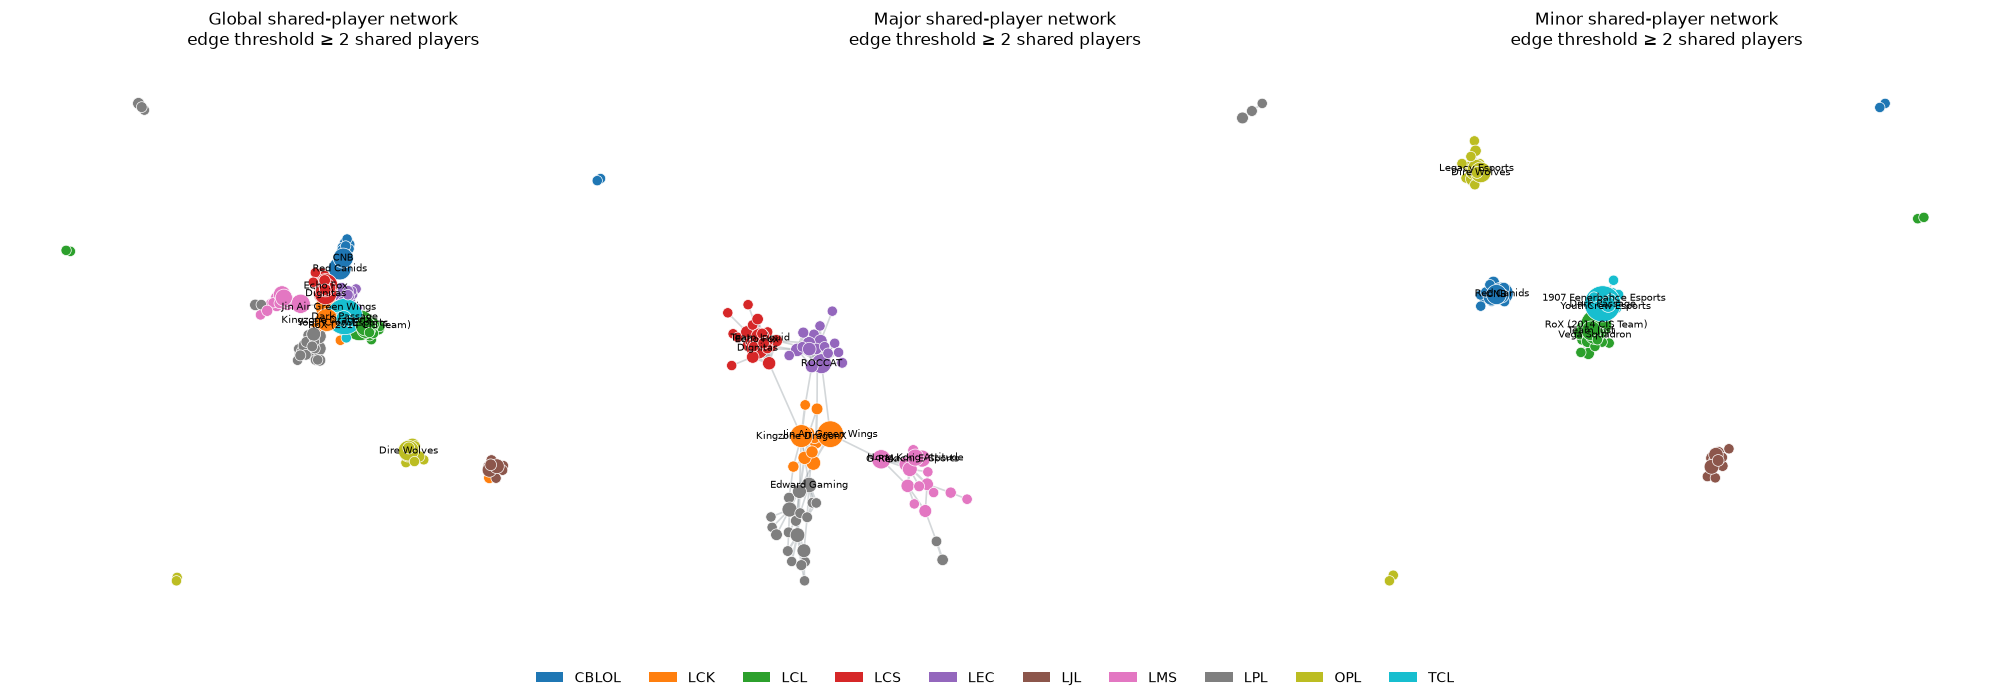

In [7]:
league_names = sorted(raw["leagues"].unique())
palette = plt.get_cmap("tab10")
league_colors = {league: palette(i) for i, league in enumerate(league_names)}
VISUAL_EDGE_THRESHOLD = 2

def draw_team_view(ax, graph, name):
    strong_edges = [(u, v) for u, v, d in graph.edges(data=True) if d["weight"] >= VISUAL_EDGE_THRESHOLD]
    shown_nodes = {node for edge in strong_edges for node in edge}
    shown = graph.edge_subgraph(strong_edges).copy() if strong_edges else graph.copy()
    shown.add_nodes_from((n, graph.nodes[n]) for n in shown_nodes if n not in shown)
    if shown.number_of_nodes() == 0:
        ax.axis("off")
        return
    pos = nx.spring_layout(shown, seed=SEED, weight="weight", iterations=100)
    weights = np.array([d["weight"] for _, _, d in shown.edges(data=True)], dtype=float)
    widths = 0.4 + 2.8 * weights / weights.max() if len(weights) else []
    sizes = [55 + 2600 * betweenness.get(n, 0) for n in shown]
    colors = [league_colors[shown.nodes[n]["league"]] for n in shown]
    nx.draw_networkx_edges(shown, pos, ax=ax, width=widths, alpha=0.25, edge_color="#52616B")
    nx.draw_networkx_nodes(shown, pos, ax=ax, node_size=sizes, node_color=colors,
                           edgecolors="white", linewidths=0.5)
    label_nodes = sorted(
        shown, key=lambda n: (betweenness.get(n, 0), weighted_degree.get(n, 0)), reverse=True
    )[:10]
    labels = {n: shown.nodes[n]["label"] for n in label_nodes}
    nx.draw_networkx_labels(shown, pos, labels=labels, font_size=7, ax=ax)
    ax.set_title(
        f"{name} shared-player network\nedge threshold ≥ {VISUAL_EDGE_THRESHOLD} shared players"
    )
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (name, graph) in zip(axes, team_views.items()):
    draw_team_view(ax, graph, name)
legend = [Patch(facecolor=league_colors[x], label=x) for x in league_names]
fig.legend(handles=legend, loc="lower center", ncol=10, frameon=False)
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

## 5. League boundaries and bridge actors

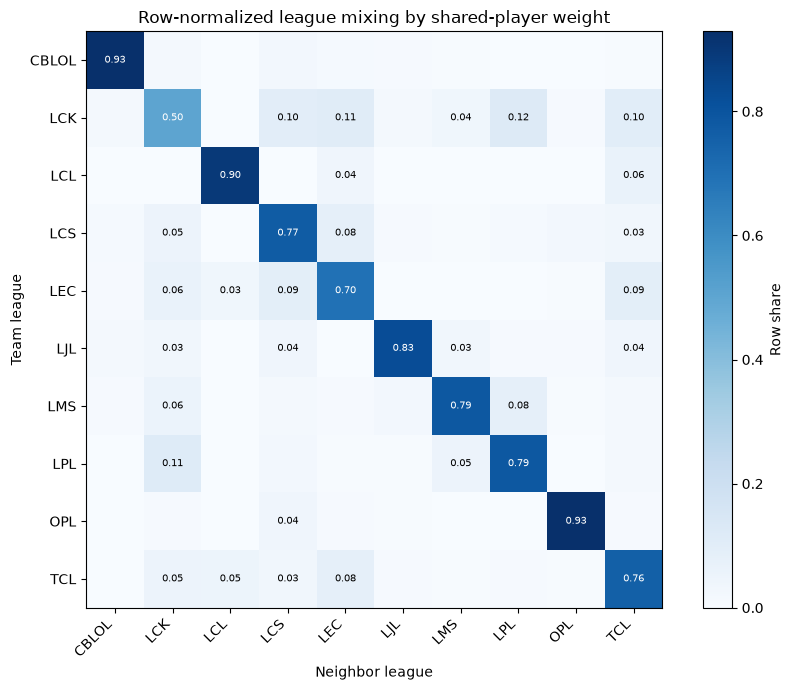

In [8]:
league_assortativity = nx.attribute_assortativity_coefficient(team_graph, "league")
group_assortativity = nx.attribute_assortativity_coefficient(team_graph, "display_group")
same_edges = [(u, v, d) for u, v, d in team_graph.edges(data=True)
              if team_graph.nodes[u]["league"] == team_graph.nodes[v]["league"]]
cross_edges = [(u, v, d) for u, v, d in team_graph.edges(data=True)
               if team_graph.nodes[u]["league"] != team_graph.nodes[v]["league"]]
total_weight = sum(d["weight"] for _, _, d in team_graph.edges(data=True))
same_weight = sum(d["weight"] for _, _, d in same_edges)

league_boundary_summary = pd.DataFrame(
    {
        "metric": [
            "League assortativity", "Major/minor assortativity",
            "Same-league edge share", "Cross-league edge share",
            "Weighted same-league share", "Weighted cross-league share",
        ],
        "value": [
            league_assortativity, group_assortativity,
            len(same_edges) / team_graph.number_of_edges(),
            len(cross_edges) / team_graph.number_of_edges(),
            same_weight / total_weight, 1 - same_weight / total_weight,
        ],
    }
)

league_mixing = pd.DataFrame(0.0, index=league_names, columns=league_names)
for u, v, attrs in team_graph.edges(data=True):
    lu, lv, weight = team_graph.nodes[u]["league"], team_graph.nodes[v]["league"], attrs["weight"]
    league_mixing.loc[lu, lv] += weight
    league_mixing.loc[lv, lu] += weight
normalized_league_mixing = league_mixing.div(league_mixing.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(normalized_league_mixing, cmap="Blues", vmin=0, vmax=normalized_league_mixing.to_numpy().max())
ax.set_xticks(range(len(league_names)), league_names, rotation=45, ha="right")
ax.set_yticks(range(len(league_names)), league_names)
for i in range(len(league_names)):
    for j in range(len(league_names)):
        value = normalized_league_mixing.iloc[i, j]
        if value >= 0.03:
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if value > 0.45 else "black")
ax.set_title("Row-normalized league mixing by shared-player weight")
ax.set_xlabel("Neighbor league")
ax.set_ylabel("Team league")
fig.colorbar(image, ax=ax, label="Row share")
plt.tight_layout()
plt.show()

strongest_cross_league = pd.DataFrame(
    {
        "team_a": team_graph.nodes[u]["label"],
        "league_a": team_graph.nodes[u]["league"],
        "team_b": team_graph.nodes[v]["label"],
        "league_b": team_graph.nodes[v]["league"],
        "shared_players": d["weight"],
    }
    for u, v, d in cross_edges
).sort_values(["shared_players", "team_a", "team_b"], ascending=[False, True, True]).head(20)

In [9]:
bridge_rows = []
for node in team_graph:
    neighbors = list(team_graph.neighbors(node))
    own_league = team_graph.nodes[node]["league"]
    neighbor_leagues = {team_graph.nodes[n]["league"] for n in neighbors}
    bridge_rows.append(
        {
            "team_node": node,
            "team_name": team_graph.nodes[node]["label"],
            "league": own_league,
            "group": team_graph.nodes[node]["display_group"],
            "degree": degree[node],
            "weighted_degree": weighted_degree[node],
            "betweenness": betweenness[node],
            "connected_leagues": len(neighbor_leagues),
            "cross_league_neighbors": sum(team_graph.nodes[n]["league"] != own_league for n in neighbors),
        }
    )
bridge_teams = (
    pd.DataFrame(bridge_rows)
      .sort_values(["betweenness", "cross_league_neighbors", "weighted_degree"], ascending=False)
      .head(20).reset_index(drop=True)
)

player_bridge_rows = []
for player_node, frame in edge_table.groupby("player_node", sort=True):
    leagues = split_values(frame["leagues"])
    raw_groups = set(split_values(frame["group"]))
    groups = sorted("minor" if value == "wildcard" else value for value in raw_groups)
    player_bridge_rows.append(
        {
            "player_node": player_node,
            "player_name": frame["player_name"].iloc[-1],
            "teams": frame["team_node"].nunique(),
            "leagues": len(leagues),
            "leagues_represented": ", ".join(leagues),
            "major_minor_bridge": {"major", "minor"}.issubset(groups),
            "total_games": frame["games_total"].sum(),
        }
    )
player_bridge_table = pd.DataFrame(player_bridge_rows)
top_player_league_bridges = (
    player_bridge_table.sort_values(["leagues", "teams", "total_games"], ascending=False)
                       .head(20).reset_index(drop=True)
)
major_minor_player_bridges = (
    player_bridge_table[player_bridge_table["major_minor_bridge"]]
      .sort_values(["leagues", "teams", "total_games"], ascending=False)
      .head(20).reset_index(drop=True)
)
print("Bridge team and bridge player tables are ready.")

Bridge team and bridge player tables are ready.


## 6. Community detection

In [10]:
if hasattr(nx.community, "louvain_communities"):
    community_method = "Louvain"
    communities = nx.community.louvain_communities(team_graph, weight="weight", seed=SEED)
else:
    community_method = "Greedy modularity"
    communities = list(nx.community.greedy_modularity_communities(team_graph, weight="weight"))

community_assignment = {
    node: community_id
    for community_id, members in enumerate(communities, start=1)
    for node in members
}
community_modularity = nx.community.modularity(team_graph, communities, weight="weight")
community_sizes = pd.DataFrame(
    {"community": range(1, len(communities) + 1), "teams": [len(c) for c in communities]}
).sort_values("teams", ascending=False)

community_league_rows = []
for community_id, members in enumerate(communities, start=1):
    counts = pd.Series([team_graph.nodes[n]["league"] for n in members]).value_counts()
    for league, count in counts.items():
        community_league_rows.append(
            {"community": community_id, "league": league, "teams": count, "share": count / len(members)}
        )
community_league_composition = pd.DataFrame(community_league_rows)

try:
    from sklearn.metrics import normalized_mutual_info_score
    ordered_nodes = sorted(team_graph)
    nmi = normalized_mutual_info_score(
        [team_graph.nodes[n]["league"] for n in ordered_nodes],
        [community_assignment[n] for n in ordered_nodes],
    )
    agreement_note = f"NMI with league labels: {nmi:.3f}"
except ImportError:
    nmi = np.nan
    agreement_note = "scikit-learn is unavailable; NMI was not calculated."

community_summary = pd.DataFrame(
    {"method": [community_method], "communities": [len(communities)],
     "modularity": [community_modularity], "league_nmi": [nmi]}
)
display(community_summary.round(4))
display(community_sizes.reset_index(drop=True))
display(community_league_composition.sort_values(["community", "teams"], ascending=[True, False]).round(3))
print(agreement_note)

,method,communities,modularity,league_nmi
0,Louvain,25,0.6767,NaN


,community,teams
0,9,44
1,22,30
2,16,29
3,10,25
4,19,23
5,24,22
6,8,20
7,17,20
8,1,15
9,6,1


,community,league,teams,share
0,1,LJL,14,0.933
1,1,LCK,1,0.067
2,2,LEC,1,1.000
3,3,LCL,1,1.000
4,4,LPL,1,1.000
5,5,LEC,1,1.000
6,6,LCL,1,1.000
7,7,LCL,1,1.000
8,8,LMS,19,0.950
9,8,LCK,1,0.050


scikit-learn is unavailable; NMI was not calculated.


## 7. Network position and performance

Team match and win totals are approximated by dividing player-level sums by five. Total games mainly measure exposure and longevity, not success.

In [11]:
team_performance = (
    raw.groupby("team_node", as_index=False, sort=True)
       .agg(
           team_name=("team_name", "last"),
           league=("leagues", join_values),
           raw_group=("group", join_values),
           domestic_games_player_sum=("games_domestic", "sum"),
           domestic_wins_player_sum=("wins_domestic", "sum"),
           international_games_player_sum=("games_international", "sum"),
           international_wins_player_sum=("wins_international", "sum"),
           active_year_list=("active_years", split_years),
       )
)
team_performance["group"] = team_performance["raw_group"].replace({"wildcard": "minor"})
team_performance["active_year_count"] = team_performance["active_year_list"].map(len)
team_performance["domestic_games"] = team_performance["domestic_games_player_sum"] / 5
team_performance["domestic_wins"] = team_performance["domestic_wins_player_sum"] / 5
team_performance["domestic_win_rate"] = team_performance["domestic_wins"].div(
    team_performance["domestic_games"].replace(0, np.nan)
)
team_performance["international_games"] = team_performance["international_games_player_sum"] / 5
team_performance["international_wins"] = team_performance["international_wins_player_sum"] / 5
team_performance["international_participation"] = team_performance["international_games_player_sum"] > 0
team_performance["international_games_per_active_year"] = (
    team_performance["international_games"] / team_performance["active_year_count"]
)
team_performance["international_win_rate"] = team_performance["international_wins"].div(
    team_performance["international_games"].replace(0, np.nan)
)

analysis_table = team_centrality.merge(
    team_performance[
        ["team_node", "domestic_games", "domestic_win_rate", "active_year_count",
         "international_participation", "international_games",
         "international_games_per_active_year", "international_win_rate"]
    ],
    on="team_node", how="left", validate="one_to_one",
)
analysis_table["degree_per_active_year"] = analysis_table["degree"] / analysis_table["active_year_count"]
analysis_table["weighted_degree_per_active_year"] = (
    analysis_table["weighted_degree"] / analysis_table["active_year_count"]
)
analysis_columns = [
    "team_name", "league", "group", "degree", "weighted_degree", "betweenness",
    "eigenvector", "cross_league_neighbors", "connected_leagues", "domestic_games",
    "domestic_win_rate", "active_year_count", "international_participation",
    "international_games_per_active_year", "international_win_rate",
]
analysis_table = analysis_table.merge(
    pd.DataFrame(bridge_rows)[["team_node", "cross_league_neighbors", "connected_leagues"]],
    on="team_node", how="left", validate="one_to_one",
)
team_analysis_output = (
    analysis_table.sort_values(["betweenness", "weighted_degree"], ascending=False)[analysis_columns]
                  .reset_index(drop=True)
)
print(f"Team-level analysis table: {len(team_analysis_output):,} teams.")
display(team_analysis_output.head(20).round(4))

Team-level analysis table: 244 teams.


,team_name,league,group,degree,weighted_degree,betweenness,eigenvector,cross_league_neighbors,connected_leagues,domestic_games,domestic_win_rate,active_year_count,international_participation,international_games_per_active_year,international_win_rate
0,Dark Passage,TCL,minor,44,105,0.2390,0.4121,27,8,267.0,0.4981,5,False,0.0000,NaN
1,RoX (2014 CIS Team),LCL,minor,26,54,0.1677,0.1565,7,3,185.0,0.4595,5,False,0.0000,NaN
2,Jin Air Green Wings,LCK,major,28,42,0.1195,0.0902,19,8,428.0,0.3762,5,False,0.0000,NaN
3,Echo Fox,LCS,major,32,76,0.0959,0.1060,9,5,242.0,0.3719,4,False,0.0000,NaN
4,Kingzone DragonX,LCK,major,29,49,0.0823,0.0772,19,7,375.0,0.5787,4,True,6.7500,0.5926
5,Red Canids,CBLOL,minor,19,36,0.0818,0.0212,7,5,135.0,0.5259,4,True,1.5000,0.6667
6,Dignitas,LCS,major,30,52,0.0800,0.0951,14,7,215.0,0.4465,3,False,0.0000,NaN
7,YouthCrew Esports,TCL,minor,31,56,0.0779,0.2289,17,7,187.0,0.4599,4,False,0.0000,NaN
8,Dire Wolves,OPL,minor,17,36,0.0633,0.0158,6,4,252.0,0.6151,5,True,4.2000,0.2857
9,CNB,CBLOL,minor,14,32,0.0589,0.0125,2,3,203.0,0.4433,5,False,0.0000,NaN


In [12]:
network_measures = [
    "degree", "weighted_degree", "betweenness", "eigenvector",
    "cross_league_neighbors", "connected_leagues",
    "degree_per_active_year", "weighted_degree_per_active_year",
]
outcomes = [
    "domestic_win_rate", "international_games_per_active_year",
    "international_win_rate", "active_year_count",
]
scopes = {
    "All": analysis_table,
    "Major": analysis_table[analysis_table["group"] == "major"],
    "Minor": analysis_table[analysis_table["group"] == "minor"],
}

correlation_rows = []
for scope_name, frame in scopes.items():
    for measure in network_measures:
        for outcome in outcomes:
            valid = frame[[measure, outcome]].dropna()
            if len(valid) >= 3 and valid[measure].nunique() > 1 and valid[outcome].nunique() > 1:
                result = spearmanr(valid[measure], valid[outcome])
                rho, p_value = result.statistic, result.pvalue
            else:
                rho, p_value = np.nan, np.nan
            correlation_rows.append(
                {"scope": scope_name, "network_measure": measure, "outcome": outcome,
                 "n": len(valid), "spearman_rho": rho, "p_value": p_value}
            )
network_performance_correlations = pd.DataFrame(correlation_rows)

comparison_rows = []
for scope_name, frame in scopes.items():
    for measure in network_measures[:6]:
        no_participation = frame.loc[~frame["international_participation"], measure].dropna()
        participation = frame.loc[frame["international_participation"], measure].dropna()
        if len(no_participation) >= 2 and len(participation) >= 2:
            test = mannwhitneyu(participation, no_participation, alternative="two-sided", method="auto")
            u_value, p_value = test.statistic, test.pvalue
        else:
            u_value, p_value = np.nan, np.nan
        comparison_rows.append(
            {
                "scope": scope_name, "network_measure": measure,
                "n_participation": len(participation), "median_participation": participation.median(),
                "n_no_participation": len(no_participation), "median_no_participation": no_participation.median(),
                "mann_whitney_u": u_value, "p_value": p_value,
            }
        )
international_participation_comparison = pd.DataFrame(comparison_rows)
print("Spearman correlations and participation comparisons are ready.")

Spearman correlations and participation comparisons are ready.


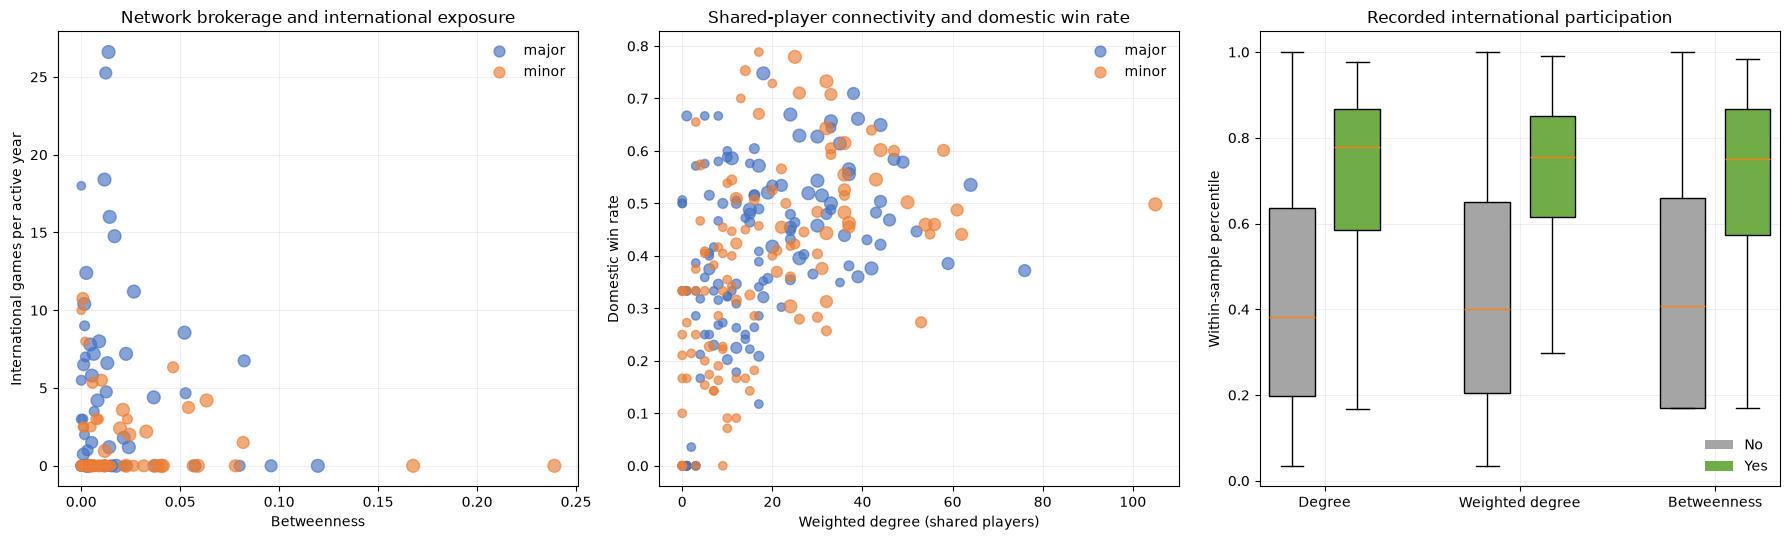

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for group_name, frame in analysis_table.groupby("group"):
    color = "#4472C4" if group_name == "major" else "#ED7D31"
    axes[0].scatter(frame["betweenness"], frame["international_games_per_active_year"],
                    s=25 + 12 * frame["active_year_count"], alpha=0.65, label=group_name, color=color)
    axes[1].scatter(frame["weighted_degree"], frame["domestic_win_rate"],
                    s=25 + 12 * frame["active_year_count"], alpha=0.65, label=group_name, color=color)
axes[0].set(xlabel="Betweenness", ylabel="International games per active year",
            title="Network brokerage and international exposure")
axes[1].set(xlabel="Weighted degree (shared players)", ylabel="Domestic win rate",
            title="Shared-player connectivity and domestic win rate")
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)

box_measures = ["degree", "weighted_degree", "betweenness"]
positions, data, colors, labels = [], [], [], []
for i, measure in enumerate(box_measures):
    ranked = analysis_table[measure].rank(pct=True)
    for j, flag in enumerate([False, True]):
        positions.append(i * 3 + j + 1)
        data.append(ranked[analysis_table["international_participation"] == flag].dropna())
        colors.append("#A5A5A5" if not flag else "#70AD47")
        labels.append("No" if not flag else "Yes")
box = axes[2].boxplot(data, positions=positions, widths=0.7, patch_artist=True, showfliers=False)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
axes[2].set_xticks([1.5, 4.5, 7.5], ["Degree", "Weighted degree", "Betweenness"])
axes[2].set(ylabel="Within-sample percentile", title="Recorded international participation")
axes[2].legend(handles=[Patch(facecolor="#A5A5A5", label="No"), Patch(facecolor="#70AD47", label="Yes")],
               frameon=False)
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8. Robustness check

In [14]:
MIN_GAMES_THRESHOLDS = [1, 5, 10]
robustness_rows = []
for threshold in MIN_GAMES_THRESHOLDS:
    kept = edge_table[edge_table["games_total"] >= threshold]
    graph = nx.Graph()
    graph.add_edges_from(kept[["player_node", "team_node"]].itertuples(index=False, name=None))
    players = set(kept["player_node"])
    teams = set(kept["team_node"])
    component_sizes = sorted((len(c) for c in nx.connected_components(graph)), reverse=True)
    robustness_rows.append(
        {
            "minimum_games": threshold,
            "nodes": graph.number_of_nodes(),
            "edges": graph.number_of_edges(),
            "components": len(component_sizes),
            "giant_component_share": component_sizes[0] / graph.number_of_nodes(),
            "density": bipartite.density(graph, players) if players and teams else np.nan,
        }
    )
robustness_results = pd.DataFrame(robustness_rows)
display(robustness_results.round(5))

,minimum_games,nodes,edges,components,giant_component_share,density
0,1,2273,3427,17,0.94897,0.00692
1,5,1943,2893,14,0.95677,0.00746
2,10,1710,2514,13,0.96316,0.00795


## 9. Final output tables

In [15]:
final_tables = [
    ("Bipartite graph summary", bipartite_summary),
    ("Global, major, and minor comparison", network_comparison),
    ("Top central teams", top_central_teams),
    ("Bridge teams", bridge_teams),
    ("Players spanning the most leagues", top_player_league_bridges),
    ("Players connecting major and minor teams", major_minor_player_bridges),
    ("League boundary summary", league_boundary_summary),
    ("League mixing matrix (row-normalized)", normalized_league_mixing),
    ("Strongest cross-league connections", strongest_cross_league),
    ("Network-performance correlations", network_performance_correlations),
    ("Recorded international participation comparison", international_participation_comparison),
    ("Robustness results", robustness_results),
]
for title, table in final_tables:
    print(f"\n{title}")
    display(table.round(4) if hasattr(table, "round") else table)


Bipartite graph summary


,metric,value
0,Graph type,Undirected weighted bipartite
1,Nodes,2273
2,Edges,3427
3,Players,2029
4,Teams,244
5,Bipartite density,0.006922
6,Connected components,17
7,Giant component size,2157
8,Giant component share,0.948966
9,Average player bipartite clustering,0.519932



Global, major, and minor comparison


,network,nodes,edges,density,components,giant_component_share,average_degree,average_weighted_degree,average_clustering
0,Global,244,1449,0.0489,17,0.9344,11.8770,18.9918,0.0677
1,Major,130,728,0.0868,12,0.9154,11.2000,16.8000,0.0869
2,Minor,114,523,0.0812,11,0.9123,9.1754,17.7018,0.0979



Top central teams


...

,scope,network_measure,outcome,n,spearman_rho,p_value
0,All,degree,domestic_win_rate,244,0.4971,0.0000
1,All,degree,international_games_per_active_year,244,0.4054,0.0000
2,All,degree,international_win_rate,55,0.3069,0.0227
3,All,degree,active_year_count,244,0.7479,0.0000
4,All,weighted_degree,domestic_win_rate,244,0.5102,0.0000
...,...,...,...,...,...,...
91,Minor,degree_per_active_year,active_year_count,114,-0.0885,0.3489
92,Minor,weighted_degree_per_active_year,domestic_win_rate,114,0.2796,0.0026
93,Minor,weighted_degree_per_active_year,international_games_per_active_year,114,0.1028,0.2762
94,Minor,weighted_degree_per_active_year,international_win_rate,20,0.1571,0.5083



Recorded international participation comparison


,scope,network_measure,n_participation,median_participation,n_no_participation,median_no_participation,mann_whitney_u,p_value
0,All,degree,55,18.0000,189,8.0000,8118.5,0.0000
1,All,weighted_degree,55,30.0000,189,11.0000,8140.5,0.0000
2,All,betweenness,55,0.0090,189,0.0001,8014.5,0.0000
3,All,eigenvector,55,0.0364,189,0.0060,7208.0,0.0000
4,All,cross_league_neighbors,55,6.0000,189,1.0000,8169.5,0.0000
5,All,connected_leagues,55,4.0000,189,2.0000,7789.5,0.0000
6,Major,degree,35,19.0000,95,9.0000,2630.5,0.0000
7,Major,weighted_degree,35,30.0000,95,12.0000,2651.0,0.0000
8,Major,betweenness,35,0.0082,95,0.0002,2580.0,0.0000
9,Major,eigenvector,35,0.0456,95,0.0065,2355.0,0.0003



Robustness results


,minimum_games,nodes,edges,components,giant_component_share,density
0,1,2273,3427,17,0.9490,0.0069
1,5,1943,2893,14,0.9568,0.0075
2,10,1710,2514,13,0.9632,0.0079


## Analysis notes

- The period is limited to 2015–2019.
- International games do not distinguish MSI from Worlds.
- Raw API responses and the collection script are unavailable.
- Team match totals are approximated from player records.
- Shared players do not establish transfer direction.
- All relationships are observational; they do not show causation.